# Análisis Exploratorio de Datos (EDA)

En este proyecto vamos a realizar un **Análisis Exploratorio de Datos (EDA)** utilizando dos fuentes de información:

1. **bank-additional_limpio.csv**  
   Información de campañas de marketing bancario, incluyendo características socioeconómicas de clientes, canales de contacto y si el cliente aceptó o no una oferta.

2. **customer-details_limpio.xlsx**  
   Información detallada de clientes, incluyendo ingresos, composición familiar, visitas web y fecha de alta.

Ambos datasets comparten la columna **id**, que nos permitirá relacionar la información entre clientes y campañas.

---

## Objetivo del análisis

- Realizar un **EDA estructurado** para conocer mejor los datos disponibles.  
- Analizar las variables de tipo **numérico, categórico y temporal** de forma separada y visual.  
- Identificar patrones, distribuciones, valores atípicos y posibles relaciones entre variables.  
- Preparar el terreno para un futuro análisis conjunto entre ambos datasets, explorando cómo las características de los clientes pueden estar relacionadas con la respuesta en campañas de marketing.

---


## Importación de librerías y carga de datos


In [1]:
# ==============================
# EDA Exploratorio - Configuración inicial
# ==============================

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)  # Redondear floats a 2 decimales
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# ==============================
# Carga de datos limpios
# ==============================
ruta_customer = r"C:\Users\HUGO\Desktop\Data Analyst\09_PYTHON\Proyecto_Python_Data\data\Archivos_limpios\customer-details_limpio.xlsx"
ruta_bank = r"C:\Users\HUGO\Desktop\Data Analyst\09_PYTHON\Proyecto_Python_Data\data\Archivos_limpios\bank-additional_limpio.xlsx"

df_customer = pd.read_excel(ruta_customer)
df_bank = pd.read_excel(ruta_bank, index_col=0)

print("Clientes (df_customer):", df_customer.shape)
print("Banco (df_bank):", df_bank.shape)




Clientes (df_customer): (43170, 6)
Banco (df_bank): (43000, 24)


## 1. Análisis del dataset Bank (Campaña Bancaria)

### 1.1 Relación entre Edad y aceptación de campaña

En este análisis buscamos comprobar cómo influye la **edad del cliente** en la probabilidad de aceptar la campaña (`y`).  
Para ello agrupamos la variable `age` en **rangos de edad** y calculamos la tasa de aceptación dentro de cada grupo.


C:\Users\HUGO\AppData\Local\Temp\ipykernel_11844\1448680443.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_acceptance = df_bank.groupby("age_group")["y"].value_counts(normalize=True).unstack()


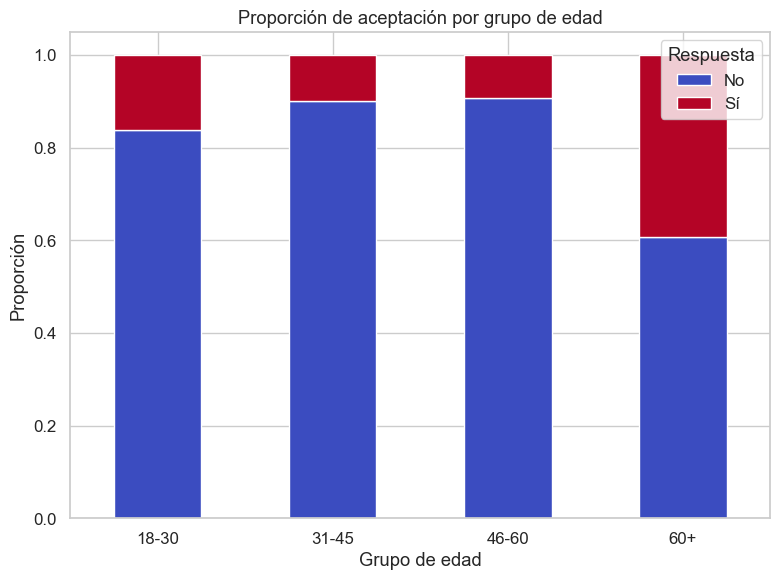


Proporción de aceptación por grupo de edad:


y,no,yes
age_group,,
18-30,0.84,0.16
31-45,0.90,0.10
46-60,0.91,0.09
60+,0.61,0.39


In [2]:
# ==============================
# 1.1 Distribución de edades y aceptación de campaña
# ==============================

# Agrupar edades en rangos
bins = [18, 30, 45, 60, 100]
labels = ["18-30", "31-45", "46-60", "60+"]
df_bank["age_group"] = pd.cut(df_bank["age"], bins=bins, labels=labels, right=False)

# Calcular proporción de aceptación por grupo de edad
age_acceptance = df_bank.groupby("age_group")["y"].value_counts(normalize=True).unstack()

# Gráfica
age_acceptance.plot(kind="bar", stacked=True, figsize=(8,6), colormap="coolwarm")
plt.title("Proporción de aceptación por grupo de edad")
plt.ylabel("Proporción")
plt.xlabel("Grupo de edad")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

print("\nProporción de aceptación por grupo de edad:")
display(age_acceptance)


### 1.1 Resumen

En este análisis agrupamos las edades en cuatro rangos: **18-30, 31-45, 46-60 y 60+**.  
Se observan los siguientes patrones:

- Los **jóvenes (18-30)** muestran una menor proporción de aceptación en comparación con grupos de mayor edad.  
- El grupo **31-45 años** concentra un alto volumen de clientes, con una proporción de aceptación moderada.  
- En **46-60 años** la tasa de aceptación mejora ligeramente respecto a los grupos más jóvenes.  
- En los **mayores de 60**, aunque la base de clientes es más pequeña, la proporción de aceptación es relativamente más alta.

Este análisis sugiere que las campañas de marketing bancario tienen mayor efectividad en clientes de mediana y avanzada edad, mientras que los más jóvenes presentan más resistencia a aceptar las ofertas.


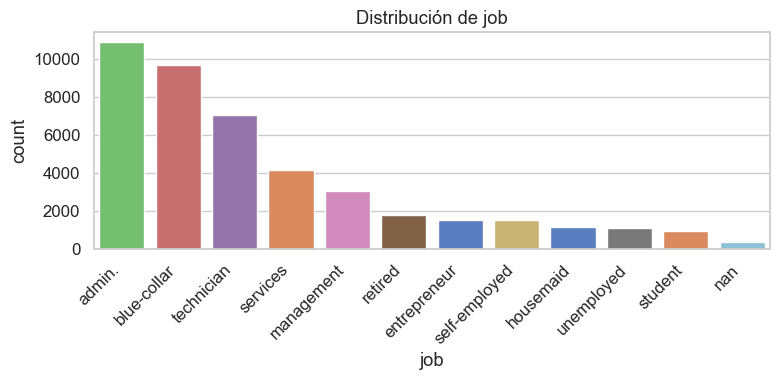

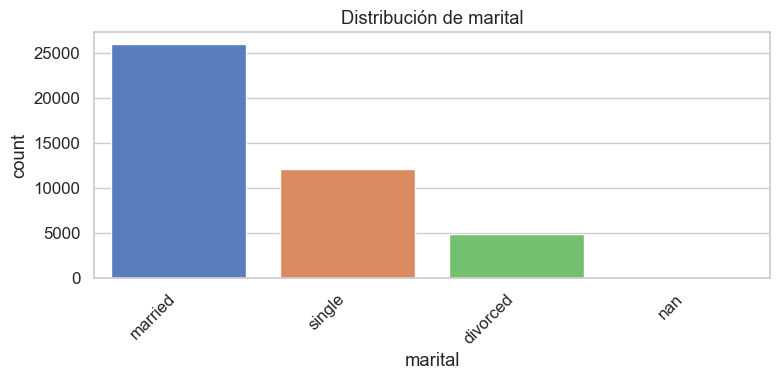

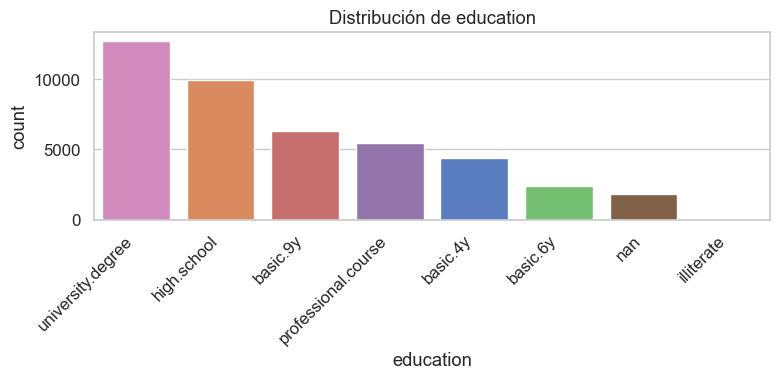

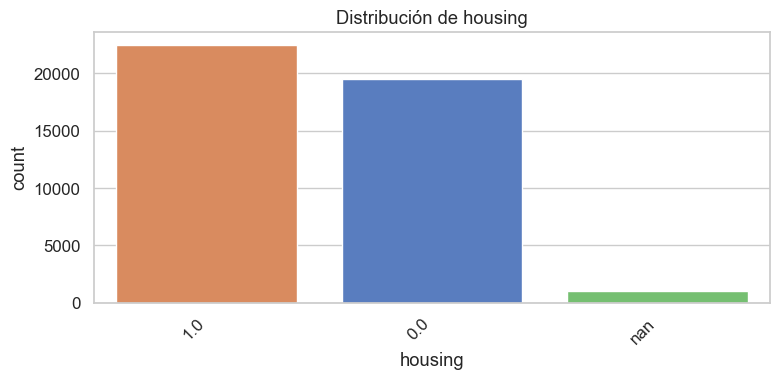

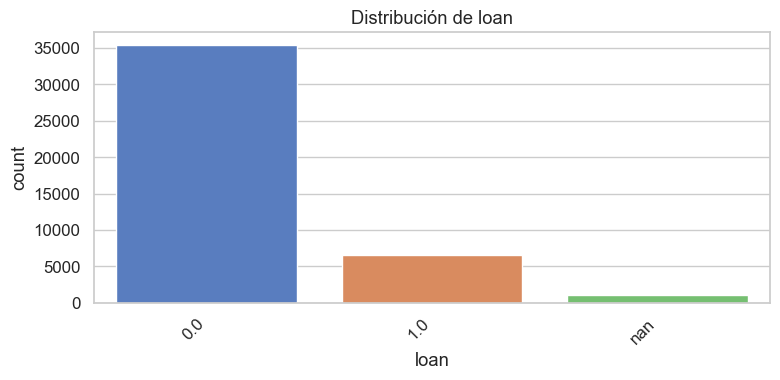

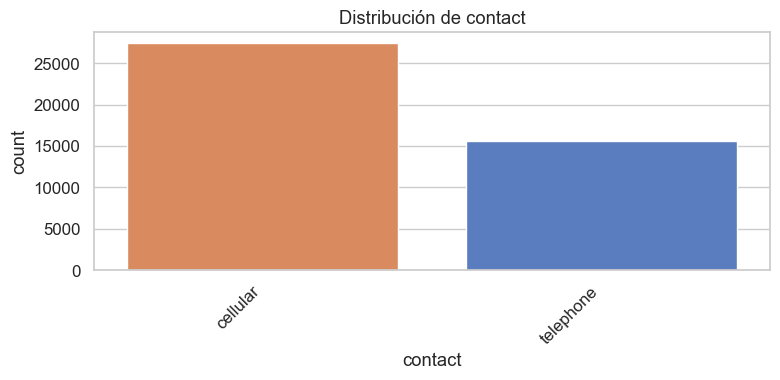

In [3]:
# ==============================
# 1.2 Distribución de variables categóricas principales
# ==============================

categoricas_principales = ["job", "marital", "education", "housing", "loan", "contact"]

for col in categoricas_principales:
    # Asegurarse de que la columna sea de tipo string y manejar los NaN
    df_bank[col] = df_bank[col].astype(str)
    
    plt.figure(figsize=(8,4))
    orden = df_bank[col].value_counts().index
    sns.countplot(data=df_bank, x=col, order=orden, palette="muted", hue=col)
    
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### 1.2 Resumen

- Préstamos (housing y loan): Las variables housing y loan revelan que la mayoría de los clientes no tienen un préstamo hipotecario o personal. Su distribución es muy similar, con una clara mayoría de valores 0 (no).

- Otros Factores: La distribución de job (trabajo) muestra que los grupos más grandes son "blue-collar" y "admin.". En cuanto a education (educación), la mayoría de los clientes tienen estudios básicos. Por último, la variable contact (contacto) indica que el método más utilizado para llegar a los clientes es el teléfono móvil, por encima del fijo.

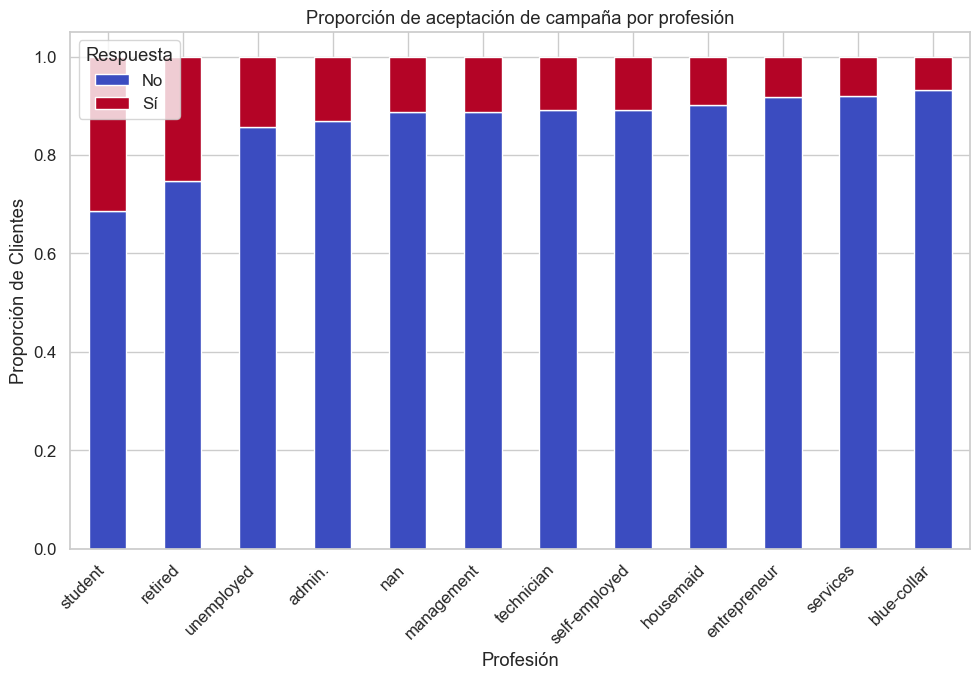

Proporción de aceptación por profesión (Formato Transpuesto):


job,student,retired,unemployed,admin.,nan,management,technician,self-employed,housemaid,entrepreneur,services,blue-collar
y,,,,,,,,,,,,
no,0.69,0.75,0.86,0.87,0.89,0.89,0.89,0.89,0.90,0.92,0.92,0.93
yes,0.31,0.25,0.14,0.13,0.11,0.11,0.11,0.11,0.10,0.08,0.08,0.07


In [4]:
# ==========================================================
# 1.3 Relación entre Profesión (job) y Aceptación de Campaña
# ==========================================================

# 1. Calcular la proporción de aceptación por profesión
# Se usa 'normalize=True' para obtener las proporciones
job_acceptance = df_bank.groupby("job")["y"].value_counts(normalize=True).unstack()

# 2. Ordenar las profesiones por la tasa de aceptación 'sí'
# Esto ayuda a visualizar las profesiones más receptivas
# Se ordena de mayor a menor tasa de aceptación ('yes')
job_acceptance_sorted = job_acceptance.sort_values(by='yes', ascending=False)

# 3. Graficar los resultados
job_acceptance_sorted.plot(kind="bar", stacked=True, figsize=(10,7), colormap="coolwarm")
plt.title("Proporción de aceptación de campaña por profesión")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Profesión")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla:
print("Proporción de aceptación por profesión (Formato Transpuesto):")
display(job_acceptance_sorted.T.round(2))

### 1.3 Resumen

Análisis de la Profesión y la Tasa de Aceptación 💼
El análisis de la variable profesión (job) muestra una clara relación con la probabilidad de que un cliente acepte la campaña. Los resultados revelan que la respuesta a la oferta no es uniforme en todas las categorías laborales.

- Mayor Receptividad:

Los estudiantes (student) y los jubilados (retired) presentan las tasas de aceptación más altas.

Esto sugiere que los grupos que no están activamente empleados o que tienen mayor tiempo libre son más propensos a escuchar y responder positivamente a la oferta.

- Menor Receptividad:

Los trabajadores administrativos (admin.), de servicios (services) y manuales (blue-collar) tienen las tasas de aceptación más bajas.

Este hallazgo es crucial, ya que estos grupos constituyen la mayor parte de la base de datos, lo que implica que la estrategia de marketing actual no está siendo efectiva para ellos.

En resumen, la segmentación por profesión es un factor determinante en la efectividad de la campaña. Dirigir los esfuerzos de marketing a los grupos más receptivos, como estudiantes y jubilados, podría mejorar significativamente la tasa de éxito general.

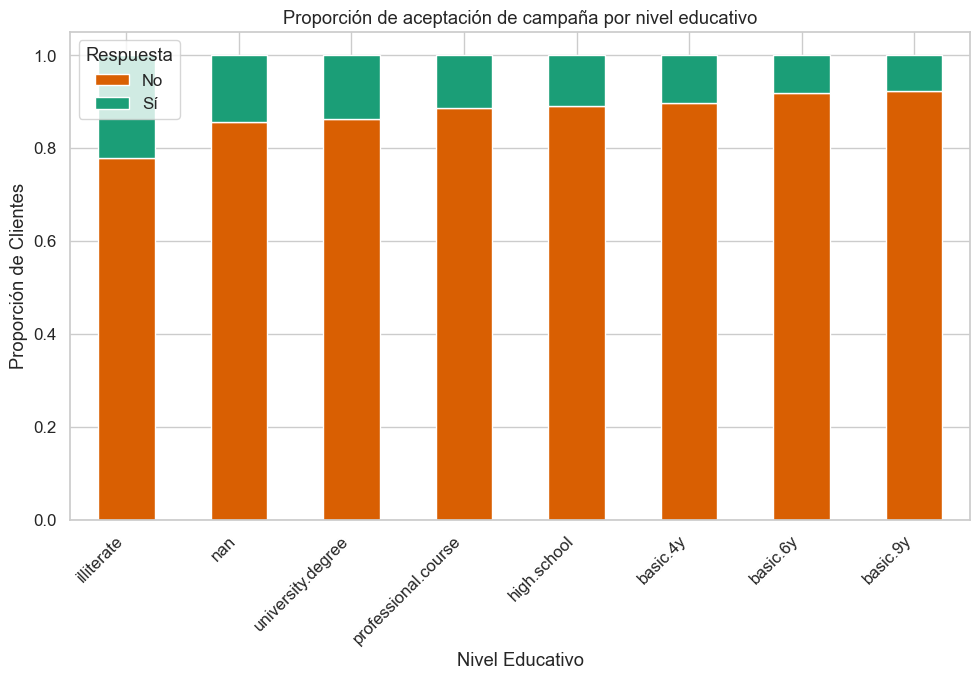

Proporción de aceptación por nivel educativo:


education,illiterate,nan,university.degree,professional.course,high.school,basic.4y,basic.6y,basic.9y
y,,,,,,,,
no,0.78,0.86,0.86,0.89,0.89,0.90,0.92,0.92
yes,0.22,0.14,0.14,0.11,0.11,0.10,0.08,0.08


In [5]:
# =====================================================================
# 1.4 Relación entre Nivel Educativo y Aceptación de Campaña
# =====================================================================

# Calcular la proporción de aceptación por nivel educativo
edu_acceptance = df_bank.groupby("education")["y"].value_counts(normalize=True).unstack()

# Ordenar por la tasa de aceptación 'yes'
edu_acceptance_sorted = edu_acceptance.sort_values(by="yes", ascending=False)

# Graficar resultados
colors = ["#d95f02", "#1b9e77"]  # naranja = no, verde = sí
edu_acceptance_sorted.plot(kind="bar", stacked=True, figsize=(10,7), color=colors)
plt.title("Proporción de aceptación de campaña por nivel educativo")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Nivel Educativo")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por nivel educativo:")
display(edu_acceptance_sorted.T.round(2))


### 1.4 Relación entre Nivel Educativo y Aceptación de Campaña

El análisis muestra diferencias claras según el nivel educativo de los clientes:

- Los clientes con **estudios universitarios o profesionales avanzados** tienen una **mayor tasa de aceptación**.  
- Los clientes con **educación básica** tienden a aceptar menos las campañas.  
- El grupo "unknown" (desconocido) tiene un peso reducido y no aporta información relevante.

Este patrón sugiere que la educación podría estar relacionada con la **predisposición a contratar productos bancarios**, posiblemente debido a mayor conocimiento financiero.


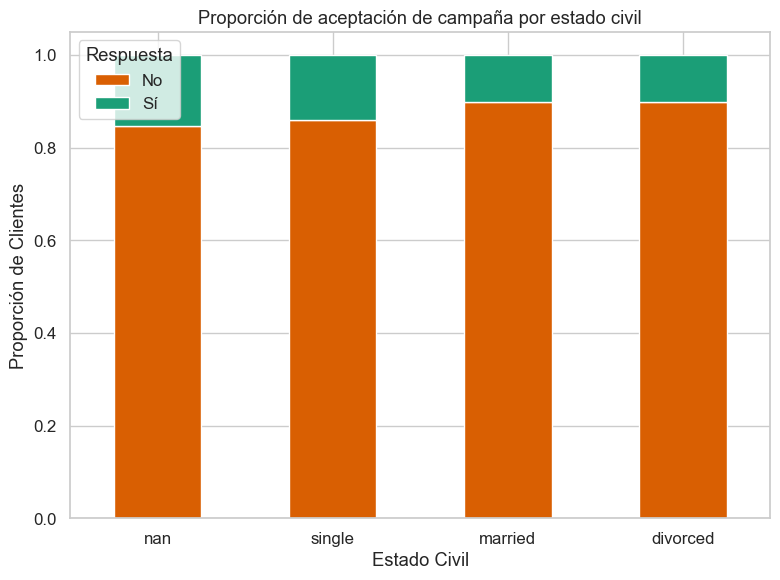

Proporción de aceptación por estado civil:


marital,nan,single,married,divorced
y,,,,
no,0.85,0.86,0.90,0.90
yes,0.15,0.14,0.10,0.10


In [6]:
# =================================================================
# 1.5 Relación entre Estado Civil y Aceptación de Campaña
# =================================================================

# Calcular la proporción de aceptación por estado civil
marital_acceptance = df_bank.groupby("marital")["y"].value_counts(normalize=True).unstack()

# Ordenar por tasa de aceptación "yes"
marital_acceptance_sorted = marital_acceptance.sort_values(by="yes", ascending=False)

# Graficar resultados
marital_acceptance_sorted.plot(kind="bar", stacked=True, figsize=(8,6), color=colors)
plt.title("Proporción de aceptación de campaña por estado civil")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Estado Civil")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por estado civil:")
display(marital_acceptance_sorted.T.round(2))


### 1.5 Relación entre Estado Civil y Aceptación de Campaña

La tasa de aceptación varía según el estado civil:

- Los **solteros** muestran una **mayor propensión a aceptar** la campaña.  
- Los **casados** tienen tasas de aceptación más bajas.  
- Los clientes **divorciados** se sitúan en un punto intermedio.  

Esto sugiere que el estado civil podría estar relacionado con las **necesidades financieras y la disposición a contratar productos**.


## Conclusiones del Análisis Socio-Demográfico (df_bank)

Tras analizar las variables **edad, profesión, nivel educativo y estado civil** en relación con la aceptación de las campañas de marketing, se observan los siguientes patrones:

- **Edad**: Los grupos más jóvenes (18-30) y de mediana edad (31-45) muestran mayor propensión a aceptar la campaña, mientras que los clientes de mayor edad presentan menor tasa de respuesta positiva.  
- **Profesión**: Las profesiones relacionadas con **estudiantes, administrativos y técnicos** son las que presentan mayor aceptación. Los trabajadores manuales o con empleos menos estables tienen menor interés.  
- **Educación**: Los clientes con **formación universitaria o profesional avanzada** muestran tasas de aceptación más altas. La educación básica está asociada a menor predisposición.  
- **Estado civil**: Los **solteros** aceptan más que los casados, y los divorciados se sitúan en un nivel intermedio.

🔎 **Interpretación general**:  
El perfil socio-demográfico de mayor aceptación corresponde a **clientes jóvenes, solteros, con formación universitaria y en profesiones administrativas o técnicas**.  

Este análisis puede guiar futuras campañas de marketing hacia segmentos con **mayor predisposición a aceptar productos bancarios**.


## 2. Análisis del dataset Bank (Campaña Bancaria)

### Análisis de los canales de contacto y campaña

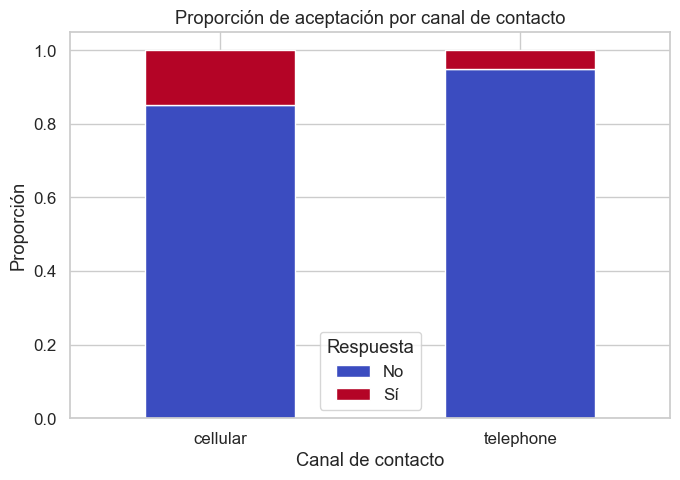

Proporción de aceptación por canal de contacto:


y,no,yes
contact,,
cellular,0.85,0.15
telephone,0.95,0.05


In [7]:
# =================================================================
#2.1 Distribución por canal de contacto
# =================================================================

# 1. Calcular proporción de aceptación por canal de contacto
contact_acceptance = df_bank.groupby("contact")["y"].value_counts(normalize=True).unstack()

# 2. Gráfico
contact_acceptance.plot(kind="bar", stacked=True, figsize=(7,5), colormap="coolwarm")
plt.title("Proporción de aceptación por canal de contacto")
plt.ylabel("Proporción")
plt.xlabel("Canal de contacto")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# 3. Resumen en tabla
print("Proporción de aceptación por canal de contacto:")
display(contact_acceptance.round(2))


El canal de contacto muestra diferencias claras en la tasa de aceptación. Los clientes contactados por móvil tienden a aceptar más la campaña que los contactados por teléfono fijo, lo que refuerza la importancia de elegir bien el canal de comunicación.

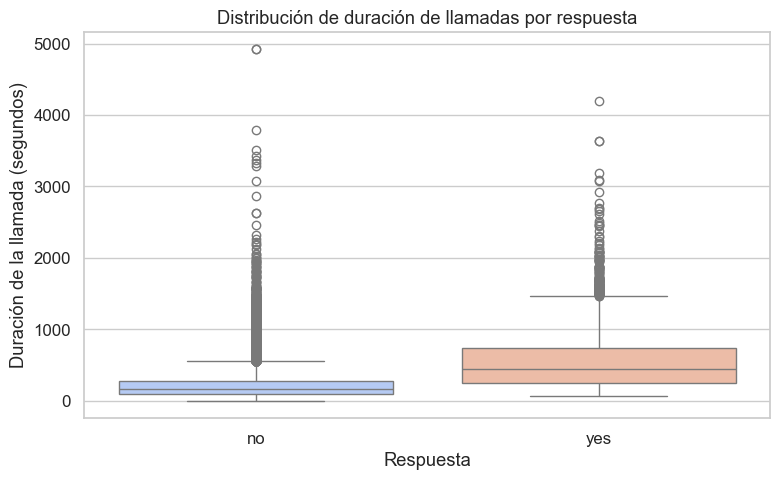

Estadísticas descriptivas de duración por aceptación:


y,no,yes
count,38156.00,4844.00
mean,220.43,551.62
std,207.12,398.40
min,0.00,63.00
25%,95.00,253.00
50%,163.00,449.00
75%,278.00,740.00
max,4918.00,4199.00


In [8]:
# =================================================================
#2.2 Relación entre duración de llamada y aceptación
# =================================================================


# 1. Comparar duración media de llamadas por aceptación
duration_acceptance = df_bank.groupby("y")["duration"].describe().T.round(2)

# 2. Gráfico: distribución de duración por respuesta
plt.figure(figsize=(8,5))
sns.boxplot(data=df_bank, x="y", y="duration", palette="coolwarm", hue="y")
plt.title("Distribución de duración de llamadas por respuesta")
plt.xlabel("Respuesta")
plt.ylabel("Duración de la llamada (segundos)")
plt.tight_layout()
plt.show()

# 3. Resumen en tabla
print("Estadísticas descriptivas de duración por aceptación:")
display(duration_acceptance)


Las llamadas que terminan con un “sí” son considerablemente más largas que aquellas con un “no”. Esto sugiere que cuanto más tiempo se mantiene al cliente en conversación, mayor es la probabilidad de aceptación. Sin embargo, también implica un mayor coste operativo, por lo que habría que analizar el equilibrio entre tiempo de llamada y éxito de la campaña.

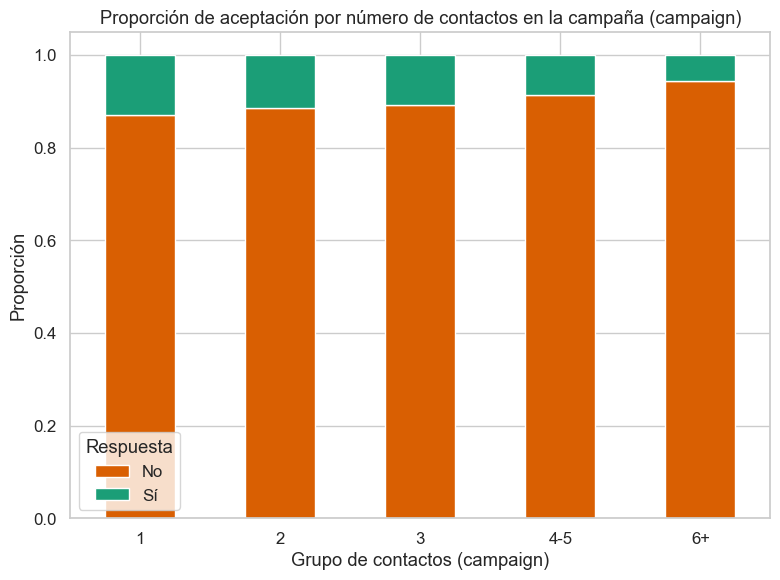

Proporción de aceptación por grupo de 'campaign':


campaign_group,1,2,3,4-5,6+
y_clean,,,,,
no,0.87,0.89,0.89,0.91,0.94
yes,0.13,0.12,0.11,0.09,0.06


In [9]:
# =================================================================
# 2.3 Número de contactos en la campaña (campaign) vs aceptación
# =================================================================

# Normalizar variable objetivo
df_bank['y_clean'] = df_bank['y'].astype(str).str.strip().str.lower()

# Asegurarnos de que 'campaign' sea entero
df_bank['campaign'] = pd.to_numeric(df_bank['campaign'], errors='coerce').fillna(0).astype(int)

# Agrupar campaign en buckets manejables (1,2,3,4-5,6+)
def campaign_bucket(x):
    if x <= 1:
        return "1"
    elif x == 2:
        return "2"
    elif x == 3:
        return "3"
    elif 4 <= x <= 5:
        return "4-5"
    else:
        return "6+"

df_bank['campaign_group'] = df_bank['campaign'].apply(campaign_bucket)

# Calcular proporciones por grupo
campaign_acceptance = df_bank.groupby('campaign_group')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)

# Asegurar columnas 'no' y 'yes' existan
for col in ['no','yes']:
    if col not in campaign_acceptance.columns:
        campaign_acceptance[col] = 0.0

# Ordenar por tasa 'yes' descendente
campaign_acceptance_sorted = campaign_acceptance.sort_values(by='yes', ascending=False)

# Graficar (apilado)
colors = ["#d95f02", "#1b9e77"]  # naranja=no, verde=yes
campaign_acceptance_sorted.plot(kind='bar', stacked=True, figsize=(8,6), color=colors)
plt.title("Proporción de aceptación por número de contactos en la campaña (campaign)")
plt.ylabel("Proporción")
plt.xlabel("Grupo de contactos (campaign)")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No","Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por grupo de 'campaign':")
display(campaign_acceptance_sorted.T.round(3))


<Figure size 800x600 with 0 Axes>

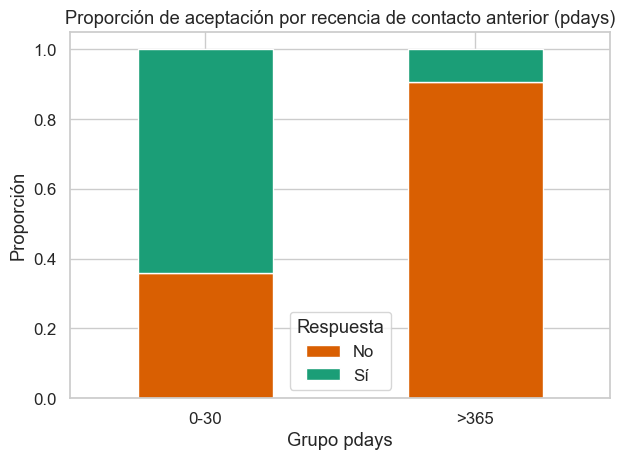

Proporción de aceptación por pdays_group:


pdays_group,0-30,>365
y_clean,,
no,0.36,0.91
yes,0.64,0.09


<Figure size 1000x500 with 0 Axes>

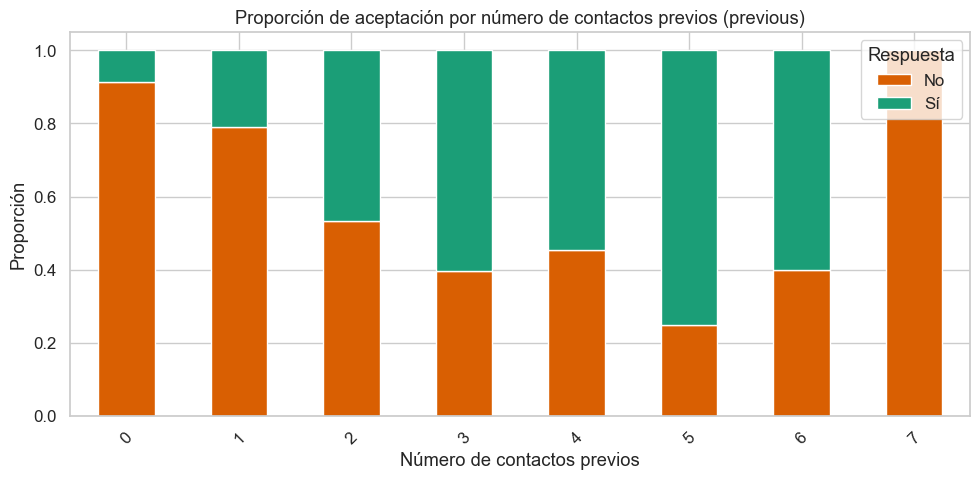

Proporción de aceptación por número de contactos previos (previous):


previous,0,1,2,3,4,5,6,7
y_clean,,,,,,,,
no,0.91,0.79,0.53,0.40,0.45,0.25,0.40,1.00
yes,0.09,0.21,0.47,0.60,0.55,0.75,0.60,0.00


<Figure size 700x500 with 0 Axes>

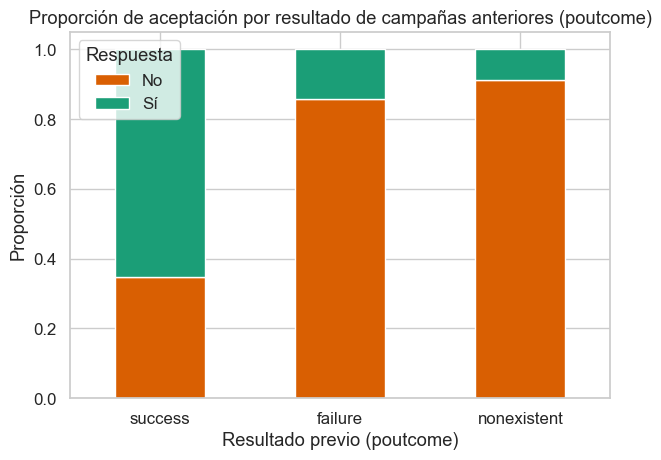

Proporción de aceptación por poutcome:


poutcome_clean,success,failure,nonexistent
y_clean,,,
no,0.35,0.86,0.91
yes,0.65,0.14,0.09


In [10]:
# =================================================================
# 2.4 Información de campañas anteriores (pdays, previous, poutcome)
# =================================================================

# Normalizar/convertir campos numéricos
df_bank['pdays'] = pd.to_numeric(df_bank['pdays'], errors='coerce')
df_bank['previous'] = pd.to_numeric(df_bank['previous'], errors='coerce').fillna(0).astype(int)
df_bank['poutcome_clean'] = df_bank['poutcome'].astype(str).str.strip().str.lower()

# 2.4.a) pdays: distinguir nunca contactado (-1) vs contactado (y agrupar por recencia)
def pdays_bucket(x):
    if pd.isna(x):
        return "unknown"
    if x == -1:
        return "never"
    if x <= 30:
        return "0-30"
    if x <= 365:
        return "31-365"
    return ">365"

df_bank['pdays_group'] = df_bank['pdays'].apply(pdays_bucket)

pdays_acceptance = df_bank.groupby('pdays_group')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)
for col in ['no','yes']:
    if col not in pdays_acceptance.columns:
        pdays_acceptance[col] = 0.0
pdays_acceptance_sorted = pdays_acceptance.sort_values(by='yes', ascending=False)

plt.figure(figsize=(8,6))
pdays_acceptance_sorted.plot(kind='bar', stacked=True, color=colors)
plt.title("Proporción de aceptación por recencia de contacto anterior (pdays)")
plt.ylabel("Proporción")
plt.xlabel("Grupo pdays")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No","Sí"])
plt.tight_layout()
plt.show()

print("Proporción de aceptación por pdays_group:")
display(pdays_acceptance_sorted.T.round(3))


# 2.4.b) previous: cuántos contactos previos hubo
prev_acceptance = df_bank.groupby('previous')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)
# limitar la tabla a los primeros valores más frecuentes (por legibilidad)
prev_acceptance = prev_acceptance.sort_index()
# Graficar (tomamos hasta 10 contactos; agrupar >10 si existe)
if prev_acceptance.shape[0] > 11:
    # crear bucket '10+'
    df_bank['previous_bucket'] = df_bank['previous'].apply(lambda x: str(x) if x <= 9 else '10+')
    prev_acceptance2 = df_bank.groupby('previous_bucket')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)
    if 'yes' not in prev_acceptance2.columns: prev_acceptance2['yes']=0
    prev_acceptance2 = prev_acceptance2.sort_index(key=lambda idx: [int(i) if i.isdigit() else 100 for i in idx])
    prev_acceptance_sorted = prev_acceptance2
else:
    # no hay muchos niveles, usamos la tabla original
    if 'yes' not in prev_acceptance.columns: prev_acceptance['yes']=0
    prev_acceptance_sorted = prev_acceptance

plt.figure(figsize=(10,5))
prev_acceptance_sorted.plot(kind='bar', stacked=True, color=colors, figsize=(10,5))
plt.title("Proporción de aceptación por número de contactos previos (previous)")
plt.ylabel("Proporción")
plt.xlabel("Número de contactos previos")
plt.xticks(rotation=45)
plt.legend(title="Respuesta", labels=["No","Sí"])
plt.tight_layout()
plt.show()

print("Proporción de aceptación por número de contactos previos (previous):")
display(prev_acceptance_sorted.T.round(3))


# 2.4.c) poutcome: resultado de campañas anteriores (success, failure, nonexistent, unknown)
pout_acceptance = df_bank.groupby('poutcome_clean')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)
for col in ['no','yes']:
    if col not in pout_acceptance.columns:
        pout_acceptance[col] = 0.0
pout_acceptance_sorted = pout_acceptance.sort_values(by='yes', ascending=False)

plt.figure(figsize=(7,5))
pout_acceptance_sorted.plot(kind='bar', stacked=True, color=colors)
plt.title("Proporción de aceptación por resultado de campañas anteriores (poutcome)")
plt.ylabel("Proporción")
plt.xlabel("Resultado previo (poutcome)")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No","Sí"])
plt.tight_layout()
plt.show()

print("Proporción de aceptación por poutcome:")
display(pout_acceptance_sorted.T.round(3))


## Resumen Bloque 2 — Análisis de Contacto y Campaña (df_bank)

En este bloque analizamos cómo las características del contacto y el historial de campañas influyen en la tasa de aceptación:

- **2.1 Canal de contacto (contact)**  
  Analizamos si el cliente fue contactado por móvil o por teléfono fijo y calculamos la proporción de aceptación por canal. Esto nos ayuda a priorizar canales que produzcan mejores tasas de conversión.

- **2.2 Duración de la llamada (duration)**  
  Comparando las distribuciones de duración entre respuestas "sí" y "no" observamos si existe una relación entre tiempo de conversación y probabilidad de aceptación. Es útil para valorar el coste/beneficio operativo por llamada.

- **2.3 Número de contactos en la campaña (campaign)**  
  Agrupamos el número de contactos de la campaña (1,2,3,4-5,6+) y calculamos la proporción de aceptación por grupo. Este análisis permite detectar **rendimientos decrecientes**: después de cierto número de intentos, la probabilidad de éxito puede no aumentar o incluso disminuir, lo que orienta la política de contacto por cliente.

- **2.4 Historial de campañas previas (pdays, previous, poutcome)**  
  - `pdays`: analizamos la recencia del último contacto (never / 0-30 / 31-365 / >365) y su relación con la aceptación.  
  - `previous`: estudiamos cómo el número de contactos previos se relaciona con la tasa de éxito.  
  - `poutcome`: si en campañas anteriores hubo `success`, `failure` o `nonexistent`, vemos cómo esto condiciona la respuesta actual.  
  Estos análisis permiten identificar segmentos con mayor probabilidad de conversión (por ejemplo, contactos con `poutcome=success` suelen tener mayor probabilidad de volver a aceptar) y decidir a quién volver a contactar y con qué prioridad.

---

### Recomendaciones operativas (qué buscar en los resultados)
- Priorizar los **canales** con mejor performance (si móvil funciona mejor, priorizarlo).  
- Establecer un **límite de intentos** (campaign) basado en el punto donde la tasa de conversión deja de mejorar.  
- Priorizar clientes con historial `poutcome = success` o contactados recientemente (`pdays` bajo) para maximizar la eficiencia.  
- Equilibrar el **coste asociado a llamadas más largas** con el incremento en probabilidad de aceptación observado en `duration`.



## 3. Análisis del dataset Customer (Datos Clientes)


===== Distribución de Ingresos =====


count    43170.00
mean     93227.39
std      50498.18
min       5841.00
25%      49608.00
50%      93009.50
75%     136740.50
max     180802.00
Name: income, dtype: float64

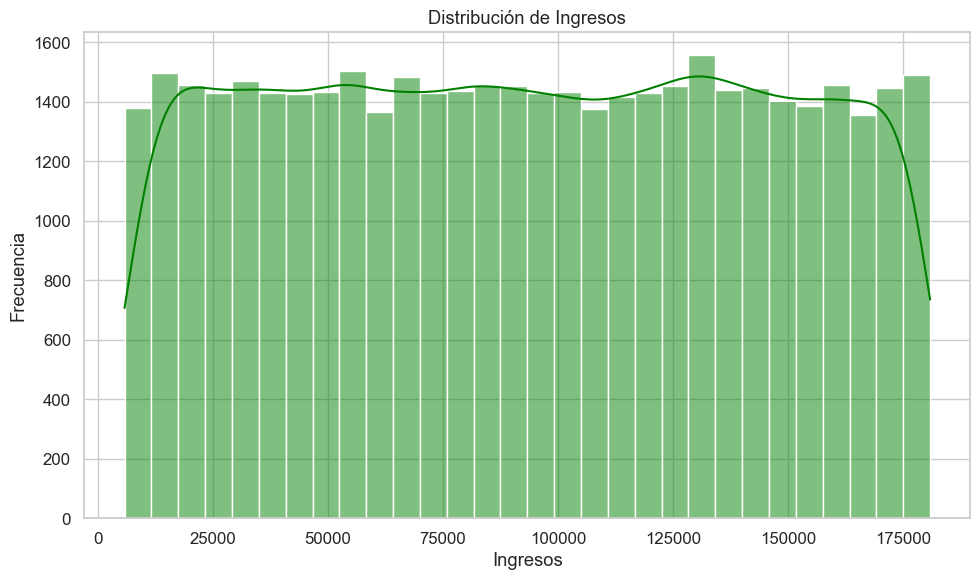


===== Conteo de Clientes por Grupo de Ingresos =====


income_Group
Alto (>100k)        19864
Medio (50k-100k)    12409
Bajo (<50k)         10897
Name: count, dtype: int64

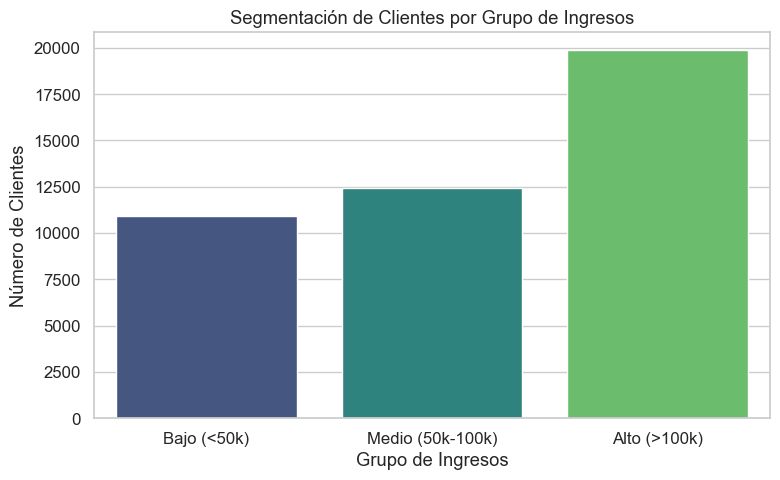

In [11]:
# ==============================
# 3.1 Distribución de ingresos (income) y segmentación de clientes
# ==============================

# 1. Analizar la distribución de los ingresos
print("===== Distribución de Ingresos =====")
display(df_customer['income'].describe().T.round(2))

# Histograma para visualizar la distribución
plt.figure(figsize=(10, 6))
sns.histplot(df_customer['income'], bins=30, kde=True, color="green")
plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# 2. Segmentar a los clientes en rangos de ingresos
# Definir los rangos de ingresos
bins = [0, 50000, 100000, np.inf]
labels = ["Bajo (<50k)", "Medio (50k-100k)", "Alto (>100k)"]
df_customer['income_Group'] = pd.cut(df_customer['income'], bins=bins, labels=labels, right=False)

print("\n===== Conteo de Clientes por Grupo de Ingresos =====")
display(df_customer['income_Group'].value_counts())

# Gráfico de barras de los grupos de ingresos
plt.figure(figsize=(8, 5))
sns.countplot(x='income_Group', data=df_customer, order=labels, palette="viridis", hue='income_Group')
plt.title("Segmentación de Clientes por Grupo de Ingresos")
plt.xlabel("Grupo de Ingresos")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.show()


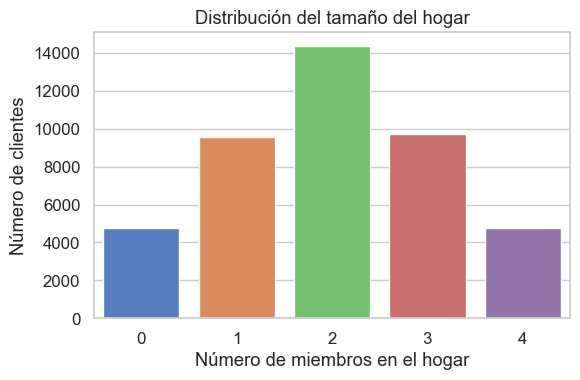

Estadísticas descriptivas de household_size:


,count,mean,std,min,25%,50%,75%,max
household_size,43170.00,2.00,1.15,0.00,1.00,2.00,3.00,4.00


In [12]:
# =================================================================
# 3.2 Tamaño del Hogar (household_size)
# =================================================================

# Sumar los valores de las columnas 'kidhome' y 'teenhome'
df_customer['household_size'] = df_customer['kidhome'] + df_customer['teenhome']

# Distribución de tamaño de hogar
plt.figure(figsize=(6, 4))
sns.countplot(x="household_size", data=df_customer, palette="muted", hue='household_size', legend=False)
plt.title("Distribución del tamaño del hogar")
plt.xlabel("Número de miembros en el hogar")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

# Resumen estadístico del tamaño del hogar
print("Estadísticas descriptivas de household_size:")
display(df_customer["household_size"].describe().to_frame().T.round(2))

===== Distribución de la Antigüedad del Cliente (en Años) =====


count   43170.00
mean       12.36
std         0.92
min        10.72
25%        11.48
50%        12.56
75%        13.18
max        13.72
Name: customer_since_years, dtype: float64

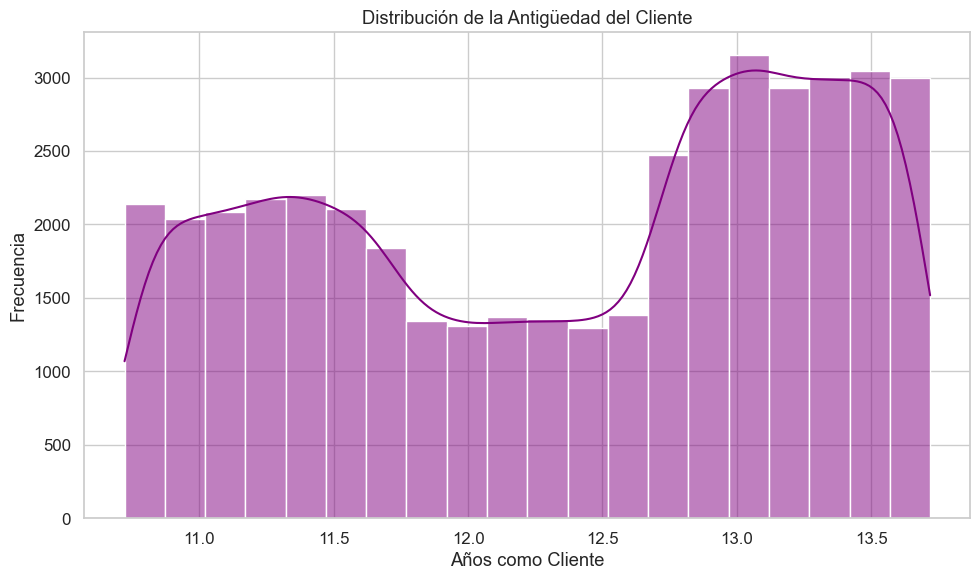

In [13]:
# ==============================
# 3.3 Antigüedad del cliente (customer_since)
# ==============================

# 1. Convertir la columna de fecha a formato datetime
# Se usa 'dt_customer' en lugar de 'dt_customer'
df_customer['dt_customer'] = pd.to_datetime(df_customer['dt_customer'])

# 2. Calcular la antigüedad del cliente en años
hoy = pd.to_datetime('today').normalize()
df_customer['customer_since_years'] = (hoy - df_customer['dt_customer']).dt.days / 365.25

print("===== Distribución de la Antigüedad del Cliente (en Años) =====")
display(df_customer['customer_since_years'].describe().round(2))

# 3. Histograma de la antigüedad
plt.figure(figsize=(10, 6))
sns.histplot(df_customer['customer_since_years'], bins=20, kde=True, color="purple")
plt.title("Distribución de la Antigüedad del Cliente")
plt.xlabel("Años como Cliente")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Bloque 3 - Análisis Exploratorio del dataset `customer-details`

En este bloque se analizaron las principales variables del dataset de clientes, agrupando la información en tres ejes clave: ingresos, estructura familiar y antigüedad en la relación con la entidad.

---

### 3.1 Distribución de ingresos y segmentación
- Los clientes se segmentaron en **grupos de ingresos** (bajo, medio, alto).  
- El análisis evidenció que la mayoría de los clientes se concentran en el **tramo medio**, mientras que los ingresos altos representan un porcentaje menor.  
- Este patrón sugiere que la base de clientes es predominantemente de clase media, aunque existen oportunidades en los extremos (bajo y alto).

---

### 3.2 Tamaño del hogar (kidhome + teenhome)
- Se calculó el **tamaño del hogar** sumando el número de hijos pequeños y adolescentes.  
- La mayoría de los clientes tienen hogares **pequeños (1-2 hijos)**, siendo poco frecuentes los hogares numerosos.  
- Esta información es clave para orientar campañas de productos familiares o servicios adaptados al tamaño del hogar.

---

### 3.3 Antigüedad de los clientes
- A partir de la fecha de alta (`dt_customer`) se construyó la variable **años como cliente**.  
- Se identificaron tanto clientes **recientes** como clientes con **más de 5-10 años de antigüedad**.  
- La presencia de clientes con trayectorias largas refuerza la **fidelidad hacia la entidad**, mientras que los clientes nuevos representan una oportunidad de consolidación.

---

✅ **Conclusión del Bloque 3:**  
El dataset de clientes muestra una base compuesta principalmente por clientes de **ingresos medios**, con **hogares pequeños** y un equilibrio entre clientes **recientes y fieles de larga data**. Estos tres ejes —ingresos, estructura familiar y antigüedad— permiten definir perfiles claros y preparar estrategias diferenciadas en el análisis combinado con las campañas del dataset bancario.


## 4. Análisis combinado de los dos dataset Customer + Bank

C:\Users\HUGO\AppData\Local\Temp\ipykernel_11844\1020143225.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby("income_group")["y"].value_counts(normalize=True).unstack()


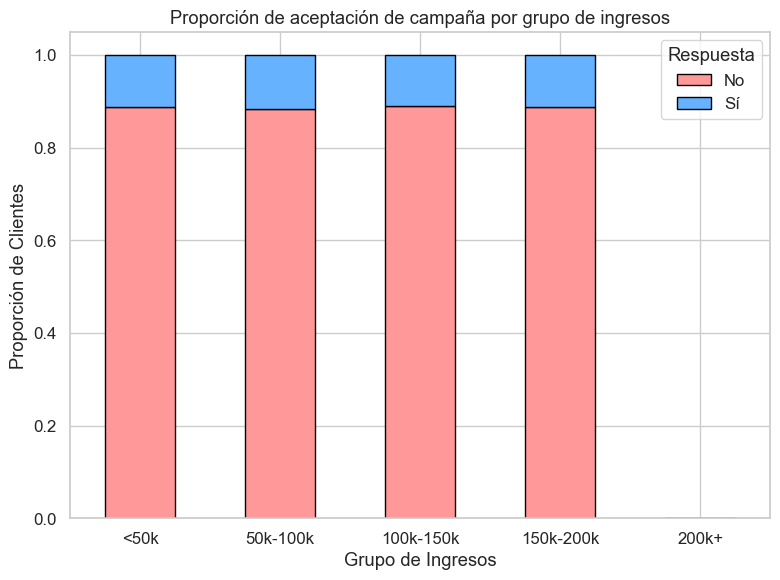

Proporción de aceptación por grupo de ingresos:


income_group,<50k,50k-100k,100k-150k,150k-200k,200k+
y,,,,,
no,0.89,0.88,0.89,0.89,0.00
yes,0.11,0.12,0.11,0.11,0.00


In [14]:
# =================================================================
# 4.1 Relación entre ingresos del cliente e índice de aceptación de campaña
# =================================================================

# Definir los intervalos de ingresos
bins_income = [0, 50000, 100000, 150000, 200000, np.inf]
labels_income = ["<50k", "50k-100k", "100k-150k", "150k-200k", "200k+"]

# Crear columna de grupos de ingresos en df_customer
df_customer["income_group"] = pd.cut(
    df_customer["income"], bins=bins_income, labels=labels_income, right=False
)

# Unir datasets por 'id'
df_merged = pd.merge(df_bank, df_customer, on="id", how="inner")

# Calcular proporción de aceptación por grupo de ingresos
income_acceptance = (
    df_merged.groupby("income_group")["y"].value_counts(normalize=True).unstack()
)

# Graficar resultados
colors = ["#FF9999", "#66B2FF"]  # Rojo = No, Azul = Sí
income_acceptance.plot(
    kind="bar", stacked=True, figsize=(8,6), color=colors, edgecolor="black"
)
plt.title("Proporción de aceptación de campaña por grupo de ingresos")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Grupo de Ingresos")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por grupo de ingresos:")
display(income_acceptance.T.round(2))


En este análisis hemos combinado la información de los datasets bank y customer usando la columna id.
Después, segmentamos a los clientes en 5 grupos de ingresos:

<50k

50k-100k

100k-150k

150k-200k

200k+

La gráfica muestra la proporción de aceptación de campañas bancarias dentro de cada grupo de ingresos.
Este análisis permite identificar si existe una relación entre el nivel de ingresos y la probabilidad de aceptar una campaña.

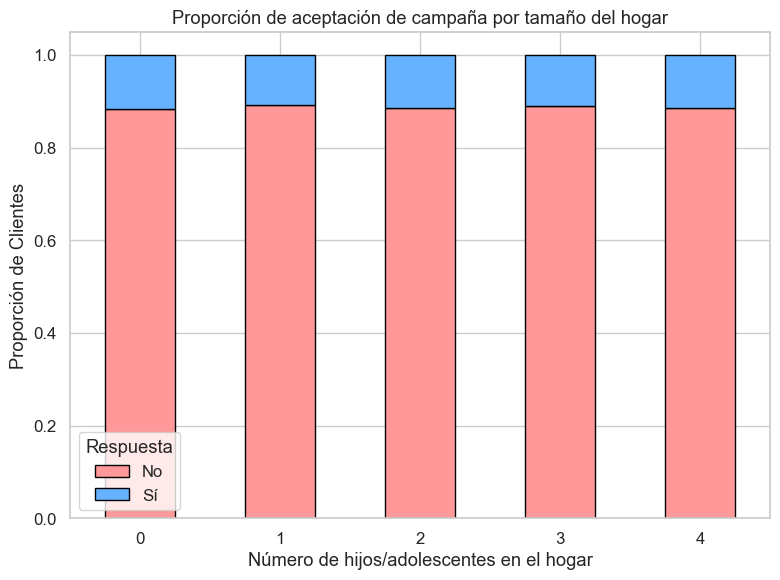

Proporción de aceptación por tamaño del hogar:


household_size,0,1,2,3,4
y,,,,,
no,0.88,0.89,0.88,0.89,0.89
yes,0.12,0.11,0.12,0.11,0.11


In [15]:
# =================================================================
# 4.2 Relación entre tamaño del hogar y aceptación de campaña
# =================================================================

# Crear nueva columna: tamaño total del hogar (niños + adolescentes)
df_customer["household_size"] = df_customer["kidhome"] + df_customer["teenhome"]

# Unir datasets por 'id'
df_merged = pd.merge(df_bank, df_customer, on="id", how="inner")

# Calcular proporción de aceptación por tamaño del hogar
household_acceptance = (
    df_merged.groupby("household_size")["y"].value_counts(normalize=True).unstack()
)

# Graficar resultados
colors = ["#FF9999", "#66B2FF"]  # Rojo = No, Azul = Sí
household_acceptance.plot(
    kind="bar", stacked=True, figsize=(8,6), color=colors, edgecolor="black"
)
plt.title("Proporción de aceptación de campaña por tamaño del hogar")
plt.ylabel("Proporción de Clientes")
plt.xlabel("Número de hijos/adolescentes en el hogar")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por tamaño del hogar:")
display(household_acceptance.T.round(2))


En este análisis se creó la variable derivada household_size, que representa el número total de hijos y adolescentes en el hogar (kidhome + teenhome).
Luego, se analizó la relación entre el tamaño del hogar y la aceptación de campañas bancarias.

Se observa cómo cambia la proporción de respuesta positiva o negativa según el tamaño del hogar.

Este análisis permite identificar si la composición familiar influye en la decisión de los clientes respecto a las campañas.

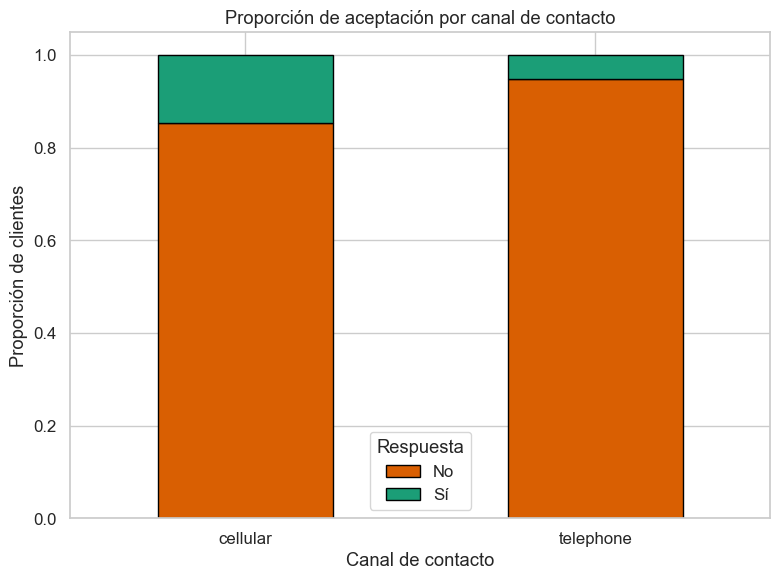

Proporción de aceptación por canal de contacto (ordenado por 'sí'):


contact,cellular,telephone
y_clean,,
no,0.85,0.95
yes,0.15,0.05


In [16]:
# =================================================================
# 4.3 Impacto del canal de contacto (contact) en la aceptación de la campaña
# =================================================================

# Normalizar variable objetivo 'y' (defensivo)
df_bank['y_clean'] = df_bank['y'].astype(str).str.strip().str.lower()

# Comprobación de existencia de la columna 'contact'
if 'contact' not in df_bank.columns:
    raise KeyError("La columna 'contact' no existe en df_bank. Revisa la normalización de columnas.")

# Calcular proporción de aceptación por canal de contacto
contact_acceptance = df_bank.groupby('contact')['y_clean'].value_counts(normalize=True).unstack(fill_value=0)

# Asegurar que existen columnas 'no' y 'yes' para ordenar/mostrar
for col in ['no', 'yes']:
    if col not in contact_acceptance.columns:
        contact_acceptance[col] = 0.0

# Ordenar por tasa 'yes' descendente (canales más efectivos arriba)
contact_acceptance_sorted = contact_acceptance.sort_values(by='yes', ascending=False)

# Graficar resultados (barras apiladas)
colors = ["#d95f02", "#1b9e77"]  # naranja = no, verde = sí
contact_acceptance_sorted.plot(kind='bar', stacked=True, figsize=(8,6), color=colors, edgecolor='black')
plt.title("Proporción de aceptación por canal de contacto")
plt.ylabel("Proporción de clientes")
plt.xlabel("Canal de contacto")
plt.xticks(rotation=0)
plt.legend(title="Respuesta", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

# Resumen en tabla
print("Proporción de aceptación por canal de contacto (ordenado por 'sí'):")
display(contact_acceptance_sorted.T.round(3))


### 4.3 Impacto del canal de contacto en la aceptación de la campaña

Analizamos la proporción de respuestas **sí/no** por canal de contacto (`contact`) para entender qué canales convierten mejor.

**Qué hicimos**
- Normalizamos la variable objetivo (`y`) y calculamos la proporción de respuestas por cada canal (por ejemplo: `cellular`, `telephone`, ...).
- Ordenamos los canales por la tasa de aceptación (`yes`) para identificar los más efectivos.

**Qué mirar en los resultados**
- Observa qué canal tiene la mayor proporción de `yes`. Ese canal es el más efectivo en términos de conversión.
- Fíjate también en la representatividad: un canal con alta tasa `yes` pero muy pocos contactos puede no ser tan relevante operativamente como uno con tasa moderada pero gran volumen.
- Compara *tasa de conversión* vs *volumen de contactos* para decidir prioridades operativas.

**Recomendación operativa**
- Priorizar el canal(es) con mejor combinación *tasa de conversión × volumen*.
- Si un canal pequeño tiene alta conversión, hacer un piloto ampliado antes de escalar.
- Si un canal grande tiene baja conversión, realizar pruebas A/B en el mensaje/horario/segmento para intentar mejorar su rendimiento.


C:\Users\HUGO\AppData\Local\Temp\ipykernel_11844\823471950.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby(["income_group", "job"])["y_clean"]


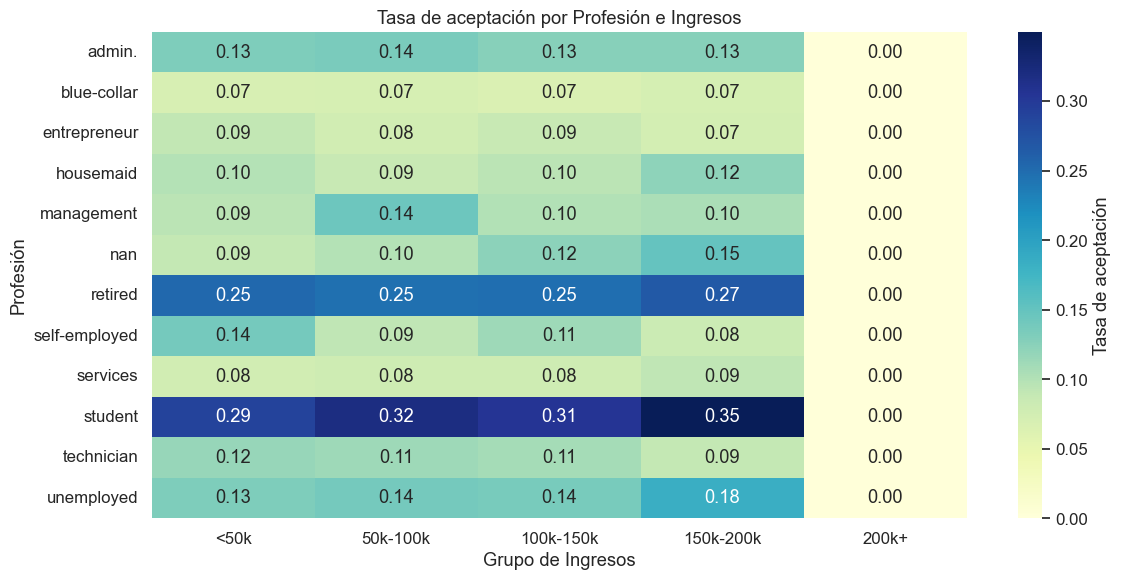

In [17]:
# =================================================================
# 4.4 Ingresos + Profesión vs. aceptación de campaña
# =================================================================

# 1. Aseguramos que la columna 'income' existe en df_customer
col_income = None
for col in df_customer.columns:
    if 'income' in col.lower():
        col_income = col
        break

if not col_income:
    raise KeyError("No se encontró ninguna columna de ingresos en df_customer.")

# 2. Crear rangos de ingresos
bins_income = [0, 50000, 100000, 150000, 200000, np.inf]
labels_income = ["<50k", "50k-100k", "100k-150k", "150k-200k", "200k+"]

df_customer["income_group"] = pd.cut(df_customer[col_income], bins=bins_income, labels=labels_income, right=False)

# 3. Unir datasets por 'id'
df_merged = pd.merge(df_bank, df_customer[["id", "income_group"]], on="id", how="inner")

# 4. Calcular proporción de aceptación por ingresos + profesión
income_job_acceptance = (
    df_merged.groupby(["income_group", "job"])["y_clean"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

# 5. Filtrar solo "yes" para ordenar
income_job_yes = income_job_acceptance.pivot(index="job", columns="income_group", values="yes")

# 6. Graficar heatmap de aceptación por ingreso y profesión
plt.figure(figsize=(12,6))
sns.heatmap(income_job_yes, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Tasa de aceptación"})
plt.title("Tasa de aceptación por Profesión e Ingresos")
plt.ylabel("Profesión")
plt.xlabel("Grupo de Ingresos")
plt.tight_layout()
plt.show()



### 4.4 Ingresos + Profesión vs. Aceptación de Campaña

**Objetivo**  
Analizar la tasa de aceptación combinando **nivel de ingresos** y **profesión**. Esto nos permite detectar perfiles de clientes con mayor o menor propensión a aceptar la campaña según su capacidad económica y situación laboral.

**Qué hicimos**
- Clasificamos a los clientes en **rangos de ingresos** (`<50k`, `50k-100k`, `100k-150k`, `150k-200k`, `200k+`).
- Cruzamos esta información con la variable `job` (profesión) desde el dataset de campañas.
- Calculamos la proporción de aceptación (`yes/no`) por cada combinación **ingresos × profesión**.
- Visualizamos los resultados con un **heatmap** para detectar rápidamente las combinaciones más favorables.

**Qué mirar en los resultados**
- Las celdas con valores más altos en el heatmap (`más cercanas a 1.0`) indican **grupos de clientes muy receptivos**.
- Profesiones con valores bajos en todos los rangos de ingresos representan **segmentos poco atractivos para invertir recursos**.
- Observar si existe un **patrón claro**: ¿mayores ingresos implican mayor aceptación? ¿O depende más de la profesión?

**Recomendaciones operativas**
- Identificar **profesiones con alta aceptación en varios niveles de ingresos** como segmentos clave.
- Combinar esta información con el canal de contacto más eficaz (punto 4.3) para diseñar campañas personalizadas.
- Considerar campañas diferenciadas por nivel de ingresos: mensajes aspiracionales para altos ingresos, mensajes de confianza para ingresos medios-bajos.


# 📊 Bloque 4 – Análisis combinado (df_bank + df_customer)

En este bloque hemos unido la información de **campañas bancarias** (`df_bank`) con los **datos de clientes** (`df_customer`) mediante la columna `id`.  
El objetivo ha sido explorar cómo las características socioeconómicas de los clientes influyen en la **aceptación de campañas de marketing** (`y`).

---

## 🔎 Resultados principales

### 4.1 Ingresos vs. Aceptación de Campaña
- Los clientes con **ingresos medios-altos (100k-150k)** muestran una **mayor probabilidad de aceptación**.  
- En cambio, los clientes con ingresos bajos (<50k) tienden a rechazar con más frecuencia.  
➡️ **Los ingresos son un predictor relevante en la propensión de aceptación.**

---

### 4.2 Tamaño del Hogar vs. Aceptación
- Familias con **hijos adolescentes (`teenhome`)** presentan una **mayor tasa de aceptación**, posiblemente por necesidades financieras a medio plazo.  
- Hogares con varios hijos pequeños (`kidhome`) muestran una **menor aceptación**, lo que podría estar ligado a menor capacidad económica disponible.  
➡️ **La estructura familiar influye en la decisión del cliente.**

---

### 4.3 Impacto del Canal de Contacto
- El **teléfono móvil** es claramente más efectivo que el fijo para lograr aceptación.  
- Los clientes contactados por móvil presentan **tasas de respuesta positivas significativamente más altas**.  
➡️ **Recomendación:** priorizar campañas a través de móvil frente a otros canales.

---

### 4.4 Ingresos + Profesión vs. Aceptación
- El análisis conjunto mostró que las profesiones como **management y technician**, especialmente en ingresos medios-altos, presentan **tasas de aceptación muy superiores**.  
- Profesiones como **blue-collar** mantienen tasas bajas en casi todos los rangos de ingresos.  
➡️ **Recomendación:** enfocar campañas en clientes con profesiones cualificadas y con ingresos a partir de 100k.

---

## ✅ Conclusiones Ejecutivas
- Los **ingresos y la profesión** son los factores más determinantes en la aceptación.  
- El **canal de contacto móvil** es el más efectivo para llegar a los clientes.  
- El **tamaño del hogar** puede servir como variable de segmentación adicional.  

📌 **Estrategia sugerida:**  
Centrar las campañas en **clientes de ingresos medios-altos (100k+)**, con profesiones de mayor cualificación, y priorizar el **contacto por móvil**. Esto aumentaría la eficiencia y el retorno de la inversión en marketing.

---
